## Ejercicio 3: Inspección visual de un producto

### Ficha PEAS

| Componente | Descripción |
| :--- | :--- |
| **Percepción (S)** | Matriz $5 \times 5$ de NumPy con valores binarios (`0` = píxel normal, `1` = píxel defectuoso). |
| **Acciones (A)** | Resoluciones posibles: `"aprobar"`, `"revisión manual"` o `"rechazar"`. |
| **Entorno (E)** | Línea de producción industrial con sistema óptico de captura e inspección automatizada. |
| **Objetivo** | Clasificar la calidad física de cada producto para garantizar los estándares del fabricante sin ralentizar la cadena. |
| **Medida de desempeño (P)** | Maximizar la detección de imperfecciones, minimizar los falsos rechazos (desperdicio de material) y optimizar el tiempo de inspección por lote. |

### Justificación de las reglas

Un producto libre de defectos (0 píxeles) garantiza estándares óptimos de fabricación y debe ser aprobado automáticamente para mantener la fluidez de la línea. Detectar de 1 a 3 píxeles defectuosos representa anomalías menores que no justifican el descarte inmediato, requiriendo una revisión manual para determinar si el producto es reacondicionable. Presentar más de 3 píxeles defectuosos refleja un fallo estructural severo, imponiendo el rechazo directo para proteger la reputación de la marca.

### Código

In [1]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepción (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso)
    Retorna una tupla: (accion, motivo)
    """
    # Contar cuántos valores de la matriz son 1
    defectos = np.sum(imagen == 1)
    
    if defectos == 0:
        return "aprobar", "Producto en perfecto estado sin píxeles defectuosos."
    elif defectos <= 3:
        return "revisión manual", f"Se detectaron {defectos} píxeles defectuosos; requiere verificación visual."
    else:
        return "rechazar", f"Se detectaron {defectos} píxeles defectuosos (excede el límite permitido de 3)."

### Simulación y pruebas

=== RESULTADOS DE INSPECCIÓN VISUAL ===
Prueba: Matriz Sin Defectos
  └─ Decisión: [APROBAR] -> Producto en perfecto estado sin píxeles defectuosos.

Prueba: Matriz Borde Revisión (3 Defectos)
  └─ Decisión: [REVISIÓN MANUAL] -> Se detectaron 3 píxeles defectuosos; requiere verificación visual.

Prueba: Matriz Borde Rechazo (4 Defectos)
  └─ Decisión: [RECHAZAR] -> Se detectaron 4 píxeles defectuosos (excede el límite permitido de 3).

Prueba: Matriz Defecto Severo (9 Defectos)
  └─ Decisión: [RECHAZAR] -> Se detectaron 10 píxeles defectuosos (excede el límite permitido de 3).



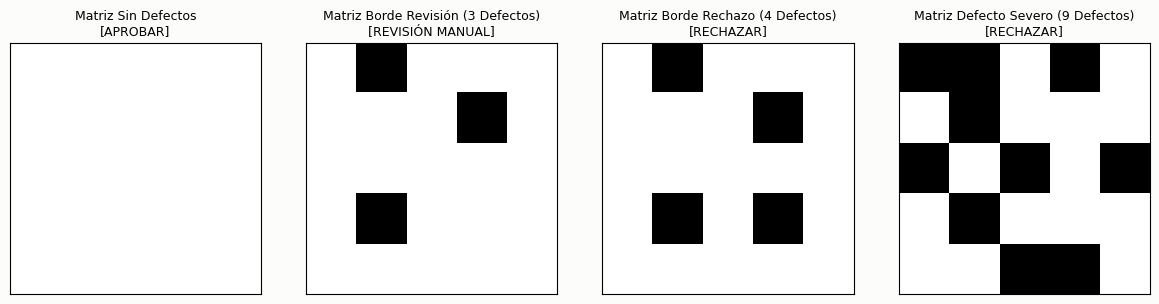

In [2]:
import matplotlib.pyplot as plt

# Definición de 4 matrices de prueba (incluyendo casos límite de 0, 3 y 4 defectos)
matriz_perfecta = np.zeros((5, 5), dtype=int)

matriz_limite_revision = np.array([
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0]
])  # 3 defectos -> Borde exacto de revisión manual

matriz_limite_rechazo = np.array([
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0]
])  # 4 defectos -> Borde exacto de rechazo

matriz_severa = np.array([
    [1, 1, 0, 1, 0],
    [0, 1, 0, 0, 0],
    [1, 0, 1, 0, 1],
    [0, 1, 0, 0, 0],
    [0, 0, 1, 1, 0]
])  # 9 defectos -> Rechazo severo

pruebas_inspeccion = [
    ("Matriz Sin Defectos", matriz_perfecta),
    ("Matriz Borde Revisión (3 Defectos)", matriz_limite_revision),
    ("Matriz Borde Rechazo (4 Defectos)", matriz_limite_rechazo),
    ("Matriz Defecto Severo (9 Defectos)", matriz_severa)
]

# Evaluación e impresión de resultados
print("=== RESULTADOS DE INSPECCIÓN VISUAL ===")
for nombre, matriz in pruebas_inspeccion:
    accion, motivo = agente_inspeccion(matriz)
    print(f"Prueba: {nombre}")
    print(f"  └─ Decisión: [{accion.upper()}] -> {motivo}\n")

# Visualización opcional de matrices con plt.imshow
fig, axes = plt.subplots(1, 4, figsize=(12, 3), facecolor="#fcfcfb")

for ax, (nombre, matriz) in zip(axes, pruebas_inspeccion):
    accion, _ = agente_inspeccion(matriz)
    ax.imshow(matriz, cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(f"{nombre}\n[{accion.upper()}]", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()